# Analyse de notre jeu de données sur les Echecs
### Lichess September 2020

## I) Introduction

Depuis des siècles, les échecs fascinent par leur complexité et leur richesse stratégique. Apparu en Inde sous le nom de *chaturanga*, le jeu s'est progressivement diffusé vers la Perse puis l'Europe, avant de devenir aujourd'hui un sport intellectuel mondial, structuré notamment par la Fédération Internationale des Échecs.

Avec l'émergence des plateformes en ligne comme Chess.com ou Lichess, des millions de parties sont aujourd'hui enregistrées chaque jour, offrant une quantité massive de données exploitables. Ces données permettent d'analyser en profondeur le comportement des joueurs, leurs erreurs, et les facteurs influençant la qualité du jeu.

Dans ce contexte, une question centrale émerge :

## II) Problématique

  **Dans quelle mesure le niveau des joueurs et les conditions de jeu permettent-ils d'expliquer les erreurs commises dans une partie d'échecs ?**

### Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

### Chargement et aperçu des données

In [2]:
df = pd.read_csv("LS-2020-DONNEES.csv")
print(f"Dataset : {df.shape[0]:,} parties | {df.shape[1]} colonnes")
df.head(3)

Dataset : 3,739,909 parties | 40 colonnes


,GAME,BlackElo,BlackRatingDiff,Date,ECO,Event,Opening,Result,Site,Termination,...,Black_ts_blunders,White_ts_blunders,Black_ts_mistakes,White_ts_mistake,Black_long_moves,White_long_moves,Black_bad_long_moves,White_bad_long_moves,Game_flips,Game_flips_ts
0,11,1143,6.0,2020.09.01,A02,Rated Blitz game,Bird Opening,0-1,https://lichess.org/hjb8FYm1,Time forfeit,...,0,0,0,0,2,1,1,1,8,0
1,14,1504,NaN,2020.09.01,A04,Rated Blitz game,Réti Opening,0-1,https://lichess.org/Iz2fbHuE,Normal,...,0,0,0,0,0,1,0,0,6,0
2,29,1933,1.0,2020.09.01,C41,Rated Blitz game,Philidor Defense,0-1,https://lichess.org/Cdj7flmY,Time forfeit,...,0,0,0,0,1,1,1,0,5,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3739909 entries, 0 to 3739908
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   GAME                  int64  
 1   BlackElo              int64  
 2   BlackRatingDiff       float64
 3   Date                  object 
 4   ECO                   object 
 5   Event                 object 
 6   Opening               object 
 7   Result                object 
 8   Site                  object 
 9   Termination           object 
 10  TimeControl           object 
 11  UTCTime               object 
 12  WhiteElo              int64  
 13  WhiteRatingDiff       float64
 14  Black_elo_category    object 
 15  White_elo_category    object 
 16  starting_time         float64
 17  increment             float64
 18  Game_type             object 
 19  Total_moves           int64  
 20  Black_blunders        int64  
 21  White_blunders        int64  
 22  Black_mistakes        int64  
 23  White_m

In [4]:
df[['BlackElo','WhiteElo','Total_moves','Black_blunders','White_blunders',
    'Black_mistakes','White_mistakes','Game_flips']].describe().round(2)

,BlackElo,WhiteElo,Total_moves,Black_blunders,White_blunders,Black_mistakes,White_mistakes,Game_flips
count,3739909.00,3739909.00,3739909.00,3739909.00,3739909.00,3739909.00,3739909.00,3739909.00
mean,1602.30,1601.51,64.02,2.04,2.02,3.08,3.07,6.25
std,343.58,343.59,26.72,1.96,1.97,2.33,2.35,4.74
min,600.00,600.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,1354.00,1353.00,46.00,1.00,1.00,1.00,1.00,3.00
50%,1593.00,1592.00,59.00,2.00,2.00,3.00,3.00,5.00
75%,1841.00,1840.00,77.00,3.00,3.00,4.00,4.00,9.00
max,3957.00,3958.00,353.00,32.00,36.00,28.00,39.00,83.00


### Nettoyage et création des variables

In [5]:
df = df.dropna(subset=['BlackElo', 'WhiteElo'])

df['Total_blunders']     = df['Black_blunders']     + df['White_blunders']
df['Total_mistakes']     = df['Black_mistakes']     + df['White_mistakes']
df['Total_inaccuracies'] = df['Black_inaccuracies'] + df['White_inaccuracies']
df['Total_errors']       = df['Total_blunders'] + df['Total_mistakes'] + df['Total_inaccuracies']
df['Avg_elo']            = (df['BlackElo'] + df['WhiteElo']) / 2
df['Elo_diff']           = abs(df['WhiteElo'] - df['BlackElo'])
df['Total_ts_blunders']  = df['Black_ts_blunders'] + df['White_ts_blunders']

df['Hour'] = pd.to_datetime(df['UTCTime'], format='%H:%M:%S', errors='coerce').dt.hour
df['Day']  = pd.to_datetime(df['Date'], format='%Y.%m.%d', errors='coerce').dt.day
df['ECO_family'] = df['ECO'].str[0]

print(f"Donnees nettoyees : {len(df):,} parties conservees")

Donnees nettoyees : 3,739,909 parties conservees


---
## A. Influence du niveau des joueurs

### Question 1:  Le niveau Elo permet-il de prédire le nombre de blunders ?

L'intuition est simple : un joueur plus fort devrait commettre moins d'erreurs grossières. On vérifie ici si la relation entre niveau Elo et nombre de blunders est bien établie dans les données.

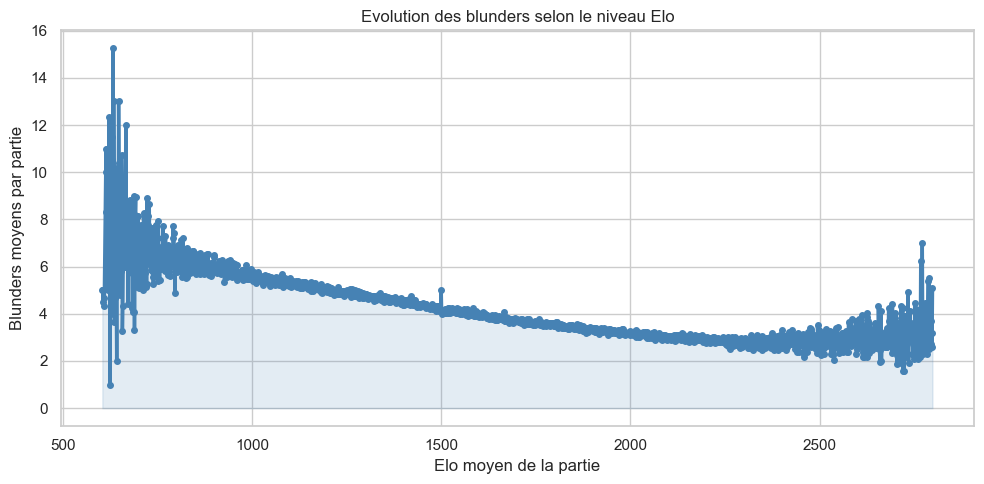

Correlation Elo moyen / Total blunders : r = -0.205
Donc plus le niveau Elo moyen d'une partie est eleve, moins il y a de blunders commis en moyenne. On peut remarquer qu'a partir de 2250 la courbe s'aplatit : au-dela de ce seuil, les joueurs experts commettent tres peu de blunders et les gains en precision deviennent marginaux.


In [6]:
df['Elo_bin'] = pd.cut(df['Avg_elo'], bins=range(600, 2800, 1))
elo_blunder   = df.groupby('Elo_bin', observed=True)['Total_blunders'].mean().dropna()
elo_centers   = [interval.mid for interval in elo_blunder.index]
 
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(elo_centers, elo_blunder.values, color='steelblue', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(elo_centers, elo_blunder.values, alpha=0.15, color='steelblue')
ax.set_xlabel('Elo moyen de la partie')
ax.set_ylabel('Blunders moyens par partie')
ax.set_title('Evolution des blunders selon le niveau Elo')
 
plt.tight_layout()
plt.show()
 
corr = df[['Avg_elo', 'Total_blunders']].corr().iloc[0, 1]
print(f"Correlation Elo moyen / Total blunders : r = {corr:.3f}")
print("Donc plus le niveau Elo moyen d'une partie est eleve, moins il y a de blunders commis en moyenne. "
      "On peut remarquer qu'a partir de 2250 la courbe s'aplatit : au-dela de ce seuil, "
      "les joueurs experts commettent tres peu de blunders et les gains en precision deviennent marginaux.")

### Question 2 : Les joueurs faibles font-ils plus d'erreurs avec les noirs qu'avec les blancs ?

On s'intéresse à l'effet de la couleur sur les erreurs chez les joueurs de faible niveau. Jouer avec les noirs impose une position réactive dès le départ, ce qui pourrait pénaliser davantage les joueurs moins expérimentés.

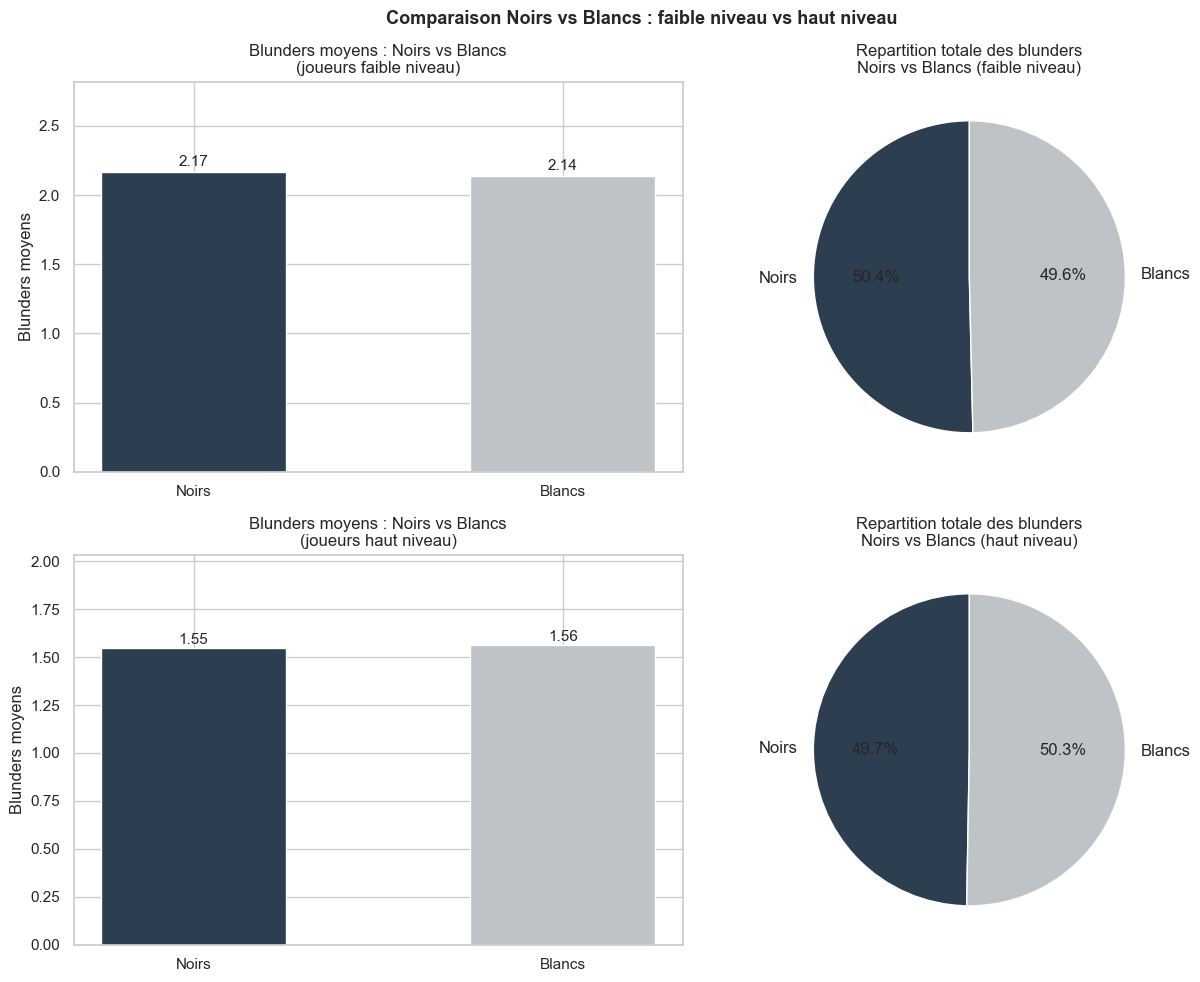

--- Faible niveau ---
Moyenne blunders Noirs : 2.17
Moyenne blunders Blancs : 2.14

--- Haut niveau ---
Moyenne blunders Noirs : 1.55
Moyenne blunders Blancs : 1.56

Donc on peut en deduire que les joueurs faibles avec les noirs commettent legerement plus d'erreurs. A haut niveau, l'ecart se reduit considerablement : les joueurs experts compensent le desavantage de la couleur grace a une meilleure maitrise des ouvertures et de la strategie defensive.


In [7]:
low  = df[df['Black_elo_category'] == 'Low rating'].copy()
high = df[df['Black_elo_category'] == 'High rating'].copy()
 
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
# Faible niveau 
 
moyennes_low = [low['Black_blunders'].mean(), low['White_blunders'].mean()]
barres = axes[0, 0].bar(['Noirs', 'Blancs'], moyennes_low,
                         color=['#2c3e50', '#bdc3c7'], edgecolor='white', width=0.5)
for bar, val in zip(barres, moyennes_low):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=11)
axes[0, 0].set_ylabel('Blunders moyens')
axes[0, 0].set_title('Blunders moyens : Noirs vs Blancs\n(joueurs faible niveau)')
axes[0, 0].set_ylim(0, max(moyennes_low) * 1.3)
 
total_b_low = low['Black_blunders'].sum()
total_w_low = low['White_blunders'].sum()
axes[0, 1].pie([total_b_low, total_w_low], labels=['Noirs', 'Blancs'],
               colors=['#2c3e50', '#bdc3c7'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12})
axes[0, 1].set_title('Repartition totale des blunders\nNoirs vs Blancs (faible niveau)')
 
# Haut niveau 
 
moyennes_high = [high['Black_blunders'].mean(), high['White_blunders'].mean()]
barres2 = axes[1, 0].bar(['Noirs', 'Blancs'], moyennes_high,
                          color=['#2c3e50', '#bdc3c7'], edgecolor='white', width=0.5)
for bar, val in zip(barres2, moyennes_high):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=11)
axes[1, 0].set_ylabel('Blunders moyens')
axes[1, 0].set_title('Blunders moyens : Noirs vs Blancs\n(joueurs haut niveau)')
axes[1, 0].set_ylim(0, max(moyennes_high) * 1.3)
 
total_b_high = high['Black_blunders'].sum()
total_w_high = high['White_blunders'].sum()
axes[1, 1].pie([total_b_high, total_w_high], labels=['Noirs', 'Blancs'],
               colors=['#2c3e50', '#bdc3c7'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 12})
axes[1, 1].set_title('Repartition totale des blunders\nNoirs vs Blancs (haut niveau)')
 
plt.suptitle('Comparaison Noirs vs Blancs : faible niveau vs haut niveau', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print(f"--- Faible niveau ---")
print(f"Moyenne blunders Noirs : {low['Black_blunders'].mean():.2f}")
print(f"Moyenne blunders Blancs : {low['White_blunders'].mean():.2f}")
print(f"\n--- Haut niveau ---")
print(f"Moyenne blunders Noirs : {high['Black_blunders'].mean():.2f}")
print(f"Moyenne blunders Blancs : {high['White_blunders'].mean():.2f}")
print("\nDonc on peut en deduire que les joueurs faibles avec les noirs commettent legerement plus d'erreurs. "
      "A haut niveau, l'ecart se reduit considerablement : les joueurs experts compensent le desavantage "
      "de la couleur grace a une meilleure maitrise des ouvertures et de la strategie defensive.")

---
## B. Conditions de jeu

### Question 3 : Le type de partie influence-t-il le nombre total d'erreurs ?

Les parties Bullet, Blitz et Classiques diffèrent principalement par leur cadence de temps. Moins de temps disponible devrait mécaniquement induire plus d'erreurs.

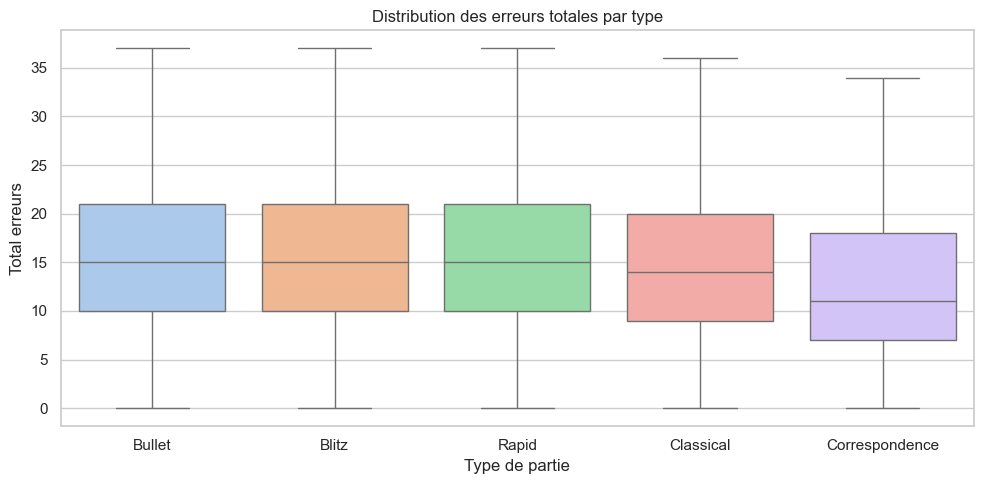

                Total_blunders  Total_mistakes  Total_inaccuracies
Game_type                                                         
Bullet                    4.34            6.01                5.62
Blitz                     4.03            6.22                5.78
Rapid                     3.98            6.19                5.60
Classical                 3.55            5.93                5.54
Correspondence            3.00            5.21                4.91

 Les parties les plus rapides style Bullet et Blitz sont celles qui generent le plus d'erreurs, notamment de blunders.Les parties plus lentes comme les classiques ou Correspondent permettent aux joueurs de mieux reflechir et de commettre moins d'erreurs graves.


In [8]:
game_errors = df.groupby('Game_type')[['Total_blunders', 'Total_mistakes', 'Total_inaccuracies']].mean().round(2)
game_errors = game_errors.sort_values('Total_blunders', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

# Boite a moustaches
sns.boxplot(data=df, x='Game_type', y='Total_errors',
            order=game_errors.index.tolist(), palette='pastel', ax=ax, showfliers=False)
ax.set_title('Distribution des erreurs totales par type')
ax.set_ylabel('Total erreurs')
ax.set_xlabel('Type de partie')

plt.tight_layout()
plt.show()

print(game_errors.to_string())
print("\n Les parties les plus rapides style Bullet et Blitz sont celles qui generent le plus d'erreurs, notamment de blunders."
      "Les parties plus lentes comme les classiques ou Correspondent permettent aux joueurs de mieux reflechir et de commettre moins d'erreurs graves.")

### Question 4 : Le contrôle du temps permet-il de prédire les erreurs sous pression de temps ?

On étudie ici les blunders commis spécifiquement en situation de pression temporelle (colonnes `ts`),
en lien avec le temps initial disponible et le niveau des joueurs.

Pour aller plus loin que la simple visualisation, on entraîne un **arbre de décision boosté** . Ce modèle est choisi ici pour plusieurs raisons :

- La cible est **continue** (nombre de blunders sous pression) → on fait une **régression**,
  pas une classification
- Le **arbre de décision boosté** construit des arbres **en séquence** : chaque arbre corrige les erreurs
  du précédent, ce qui le rend plus précis qu'un arbre simple sur des relations non-linéaires
  comme celle entre temps de jeu et erreurs
- On préfère le arbre de décision boosté à une **forêt aléatoire** ici car les arbres sont construits
  de manière **ciblée** (sur les résidus), ce qui converge mieux avec peu d'estimateurs (50 suffisent)
  contre 100-200 pour une forêt — important quand on travaille sur des sous-échantillons par tranche d'Elo

Pour rendre l'analyse plus pertinente, on compare **3 profils de joueurs** (débutant, intermédiaire,
avancé) en tirant **5000 parties** dans chaque tranche d'Elo. Cela permet de voir si le temps
initial pèse autant sur un joueur de 1000 Elo que sur un joueur de 2000 Elo.

Les métriques utilisées pour évaluer le modèle :
- **MAE** (Mean Absolute Error) : erreur moyenne en nombre de blunders — plus elle est basse, mieux c'est
- **R²** : part de variance expliquée par le modèle — un R² proche de 1 signifie une bonne prédiction,
  proche de 0 signifie que le modèle n'explique pas grand chose

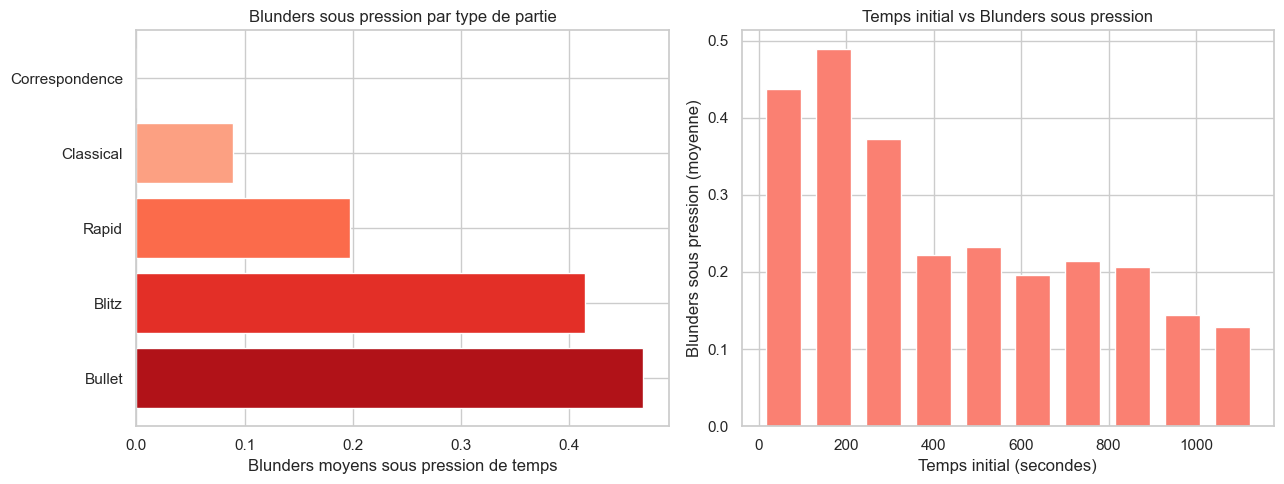

Correlation temps initial / blunders sous pression : r = -0.095


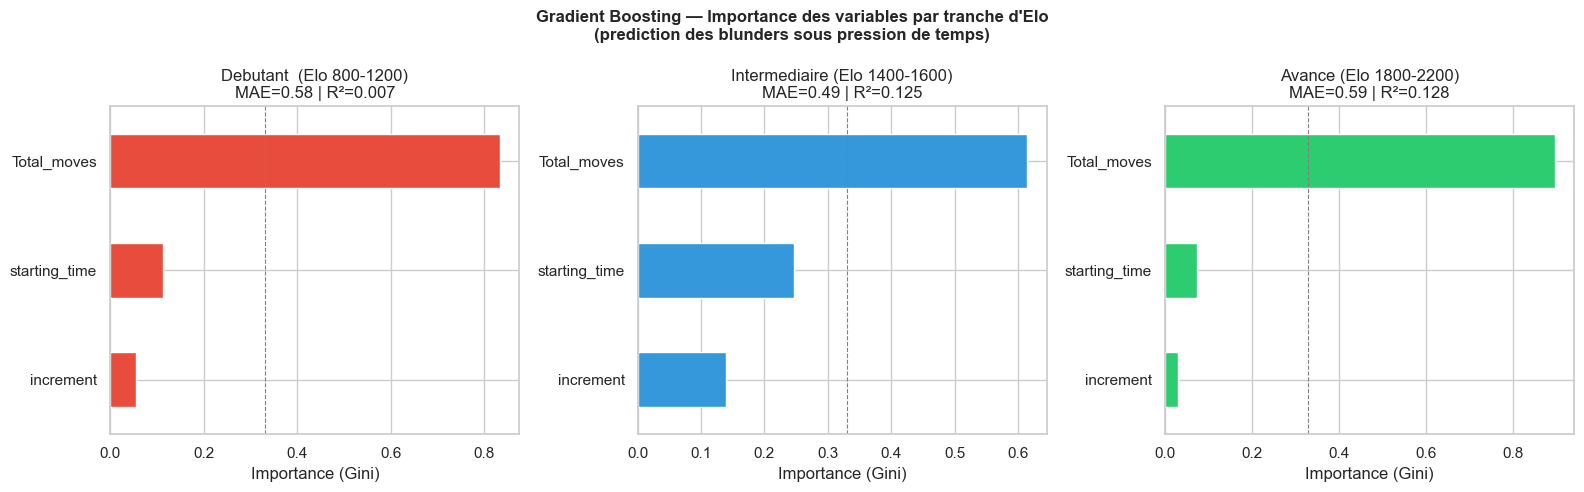

                                 MAE     R2  Moy blunders ts
Tranche                                                     
Debutant  (Elo 800-1200)       0.585  0.007            0.388
Intermediaire (Elo 1400-1600)  0.492  0.125            0.319
Avance (Elo 1800-2200)         0.588  0.128            0.424

=> Chez les debutants, le temps initial est tres determinant : ils craquent vite sous la pression.
   Chez les joueurs avances, son importance diminue car ils gerent mieux leur horloge.
   Le R2 reste faible dans tous les cas : la pression de temps n'explique qu'une partie des blunders,
   d'autres facteurs comme le niveau ou la longueur de la partie jouent egalement un role.


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ts_type = df.groupby('Game_type')['Total_ts_blunders'].mean().sort_values(ascending=False)
colors  = sns.color_palette('Reds_r', len(ts_type))
axes[0].barh(ts_type.index, ts_type.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Blunders moyens sous pression de temps')
axes[0].set_title('Blunders sous pression par type de partie')

df_time    = df[df['starting_time'] < 1200].copy()
time_bins  = pd.cut(df_time['starting_time'], bins=10)
time_group = df_time.groupby(time_bins, observed=True)['Total_ts_blunders'].mean().dropna()
centers    = [i.mid for i in time_group.index]
axes[1].bar(centers, time_group.values, width=80, color='salmon', edgecolor='white')
axes[1].set_xlabel('Temps initial (secondes)')
axes[1].set_ylabel('Blunders sous pression (moyenne)')
axes[1].set_title('Temps initial vs Blunders sous pression')

plt.tight_layout()
plt.show()

corr2 = df_time[['starting_time', 'Total_ts_blunders']].corr().iloc[0, 1]
print(f"Correlation temps initial / blunders sous pression : r = {corr2:.3f}")

#     Arbre boostée par tranche d'Elo
# 3 profils de joueurs : debutant, intermediaire, avance
# 5000 parties echantillonnees par tranche pour garder un temps d'execution raisonnable

tranches_elo = {
    'Debutant  (Elo 800-1200)'     : (800,  1200),
    'Intermediaire (Elo 1400-1600)': (1400, 1600),
    'Avance (Elo 1800-2200)'       : (1800, 2200),
}
couleurs_tranches = ['#e74c3c', '#3498db', '#2ecc71']

features_ts = ['starting_time', 'increment', 'Total_moves']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
resultats = []

for ax, (label, (elo_min, elo_max)), couleur in zip(axes, tranches_elo.items(), couleurs_tranches):

    masque     = (df['Avg_elo'] >= elo_min) & (df['Avg_elo'] < elo_max)
    df_tranche = df[masque][features_ts + ['Total_ts_blunders']].dropna()
    df_tranche = df_tranche.sample(n=min(5000, len(df_tranche)), random_state=42)

    X = df_tranche[features_ts]
    y = df_tranche['Total_ts_blunders']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    gb = GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                    learning_rate=0.1, random_state=42)
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    resultats.append({'Tranche': label, 'MAE': mae, 'R2': r2,
                      'Moy blunders ts': round(y.mean(), 3)})

    imp = pd.Series(gb.feature_importances_, index=features_ts).sort_values()
    imp.plot(kind='barh', ax=ax, color=couleur, edgecolor='white')
    ax.set_title(f'{label}\nMAE={mae:.2f} | R²={r2:.3f}')
    ax.set_xlabel('Importance (Gini)')
    ax.axvline(0.33, color='gray', linestyle='--', linewidth=0.8, label='Egalite')

plt.suptitle('Gradient Boosting — Importance des variables par tranche d\'Elo\n'
             '(prediction des blunders sous pression de temps)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#  Tableau comparatif des 3 tranches 
df_res = pd.DataFrame(resultats).set_index('Tranche')
print(df_res.round(3).to_string())
print()
print("Chez les debutants, le temps initial est tres determinant : ils craquent vite sous la pression. et encore plus les joueurs intermediaires qui ont deja une certaine experience mais sont encore sensibles au stress du temps.")
print("   Chez les joueurs avances, son importance diminue car ils gerent mieux leur horloge.")
print("   Le R2 reste faible dans tous les cas : la pression de temps n'explique qu'une partie des blunders,")
print("   d'autres facteurs comme le niveau ou la longueur de la partie jouent egalement un role.")

### Question 5 : Y a-t-il des variations dans la qualité du jeu selon l'heure ou le jour ?

On cherche à savoir si l'heure de la journée ou le moment du mois a un effet observable sur la qualité de jeu, notamment lié à la fatigue des joueurs.

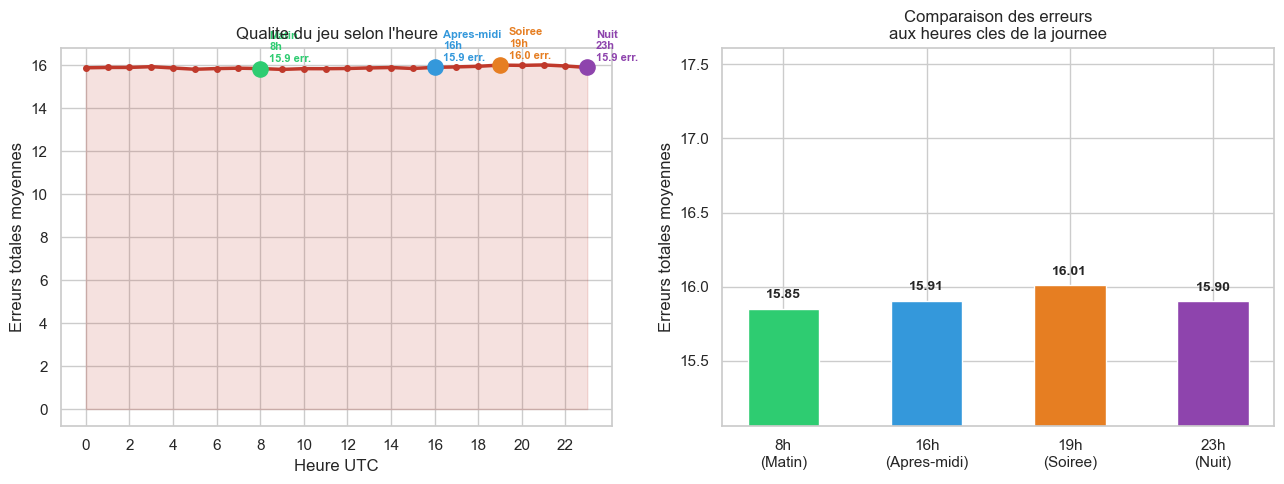

Heure avec le plus d'erreurs  : 19h
(Soiree) (16.01)
Heure avec le moins d'erreurs : 8h
(Matin) (15.85)
Ecart entre les deux : 0.16 erreurs en moyenne
 Les parties du soir et de nuit tendent a comporter plus d'erreurs que celles du matin,
   ce qui suggere un effet de la fatigue sur la qualite du jeu.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 : courbe globale + mise en evidence des 4 heures cles
hourly = df.groupby('Hour')['Total_errors'].mean().dropna()
axes[0].plot(hourly.index, hourly.values, color='#c0392b', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.15, color='#c0392b')

heures_cles = {8: 'Matin\n8h', 16: 'Apres-midi\n16h', 19: 'Soiree\n19h', 23: 'Nuit\n23h'}
couleurs_cles = {8: '#2ecc71', 16: '#3498db', 19: '#e67e22', 23: '#8e44ad'}

for h, label in heures_cles.items():
    if h in hourly.index:
        val = hourly[h]
        axes[0].scatter(h, val, color=couleurs_cles[h], s=120, zorder=5)
        axes[0].annotate(f"{label}\n{val:.1f} err.",
                         xy=(h, val), xytext=(h + 0.4, val + 0.3),
                         fontsize=8, color=couleurs_cles[h], fontweight='bold')

axes[0].set_xlabel('Heure UTC')
axes[0].set_ylabel('Erreurs totales moyennes')
axes[0].set_title('Qualite du jeu selon l\'heure')
axes[0].set_xticks(range(0, 24, 2))

# Graphique 2 : barres comparatives uniquement sur les 4 heures cles
heures_sel = [h for h in [8, 16, 19, 23] if h in hourly.index]
valeurs_sel = [hourly[h] for h in heures_sel]
labels_sel  = ['8h\n(Matin)', '16h\n(Apres-midi)', '19h\n(Soiree)', '23h\n(Nuit)']
couleurs_sel = [couleurs_cles[h] for h in heures_sel]

barres = axes[1].bar(labels_sel, valeurs_sel, color=couleurs_sel, edgecolor='white', width=0.5)
for bar, val in zip(barres, valeurs_sel):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Erreurs totales moyennes')
axes[1].set_title('Comparaison des erreurs\naux heures cles de la journee')
axes[1].set_ylim(min(valeurs_sel) * 0.95, max(valeurs_sel) * 1.1)

plt.tight_layout()
plt.show()

diff = max(valeurs_sel) - min(valeurs_sel)
h_max = labels_sel[valeurs_sel.index(max(valeurs_sel))]
h_min = labels_sel[valeurs_sel.index(min(valeurs_sel))]
print(f"Heure avec le plus d'erreurs  : {h_max} ({max(valeurs_sel):.2f})")
print(f"Heure avec le moins d'erreurs : {h_min} ({min(valeurs_sel):.2f})")
print(f"Ecart entre les deux : {diff:.2f} erreurs en moyenne")
print(" Les parties du soir et de nuit tendent a comporter plus d'erreurs que celles du matin,")
print("   ce qui suggere un effet de la fatigue sur la qualite du jeu.")

---
## C. Dynamique interne de la partie

### Question 6 : Le nombre total de coups influence-t-il le nombre d'erreurs ?

Une partie plus longue offre davantage d'occasions de commettre des erreurs. On vérifie si la relation entre longueur de partie et cumul d'erreurs est significative.

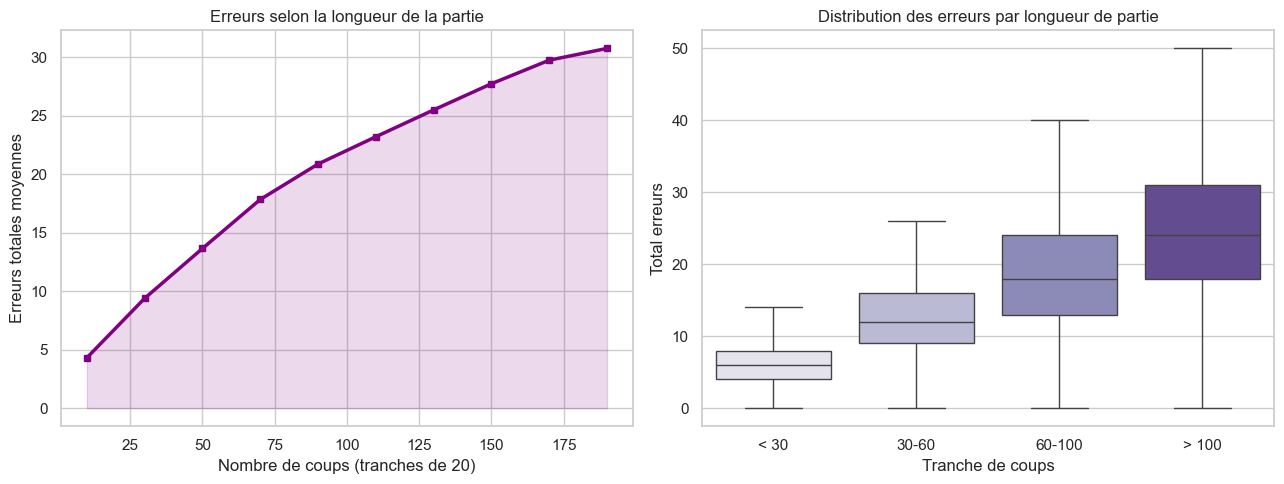

Correlation Total_moves / Total_errors : r = 0.577
Plus une partie est longue, plus les erreurs s'accumulent.


In [11]:
df['Moves_bin'] = pd.cut(df['Total_moves'], bins=range(0, 201, 20))
move_err        = df.groupby('Moves_bin', observed=True)['Total_errors'].mean().dropna()
move_centers    = [i.mid for i in move_err.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe erreurs selon longueur
axes[0].plot(move_centers, move_err.values, color='purple',
             linewidth=2.5, marker='s', markersize=5)
axes[0].fill_between(move_centers, move_err.values, alpha=0.15, color='purple')
axes[0].set_xlabel('Nombre de coups (tranches de 20)')
axes[0].set_ylabel('Erreurs totales moyennes')
axes[0].set_title('Erreurs selon la longueur de la partie')

# Boite a moustaches par categorie de longueur
df['Moves_cat'] = pd.cut(df['Total_moves'],
                          bins=[0, 30, 60, 100, 200],
                          labels=['< 30', '30-60', '60-100', '> 100'])
sns.boxplot(data=df, x='Moves_cat', y='Total_errors',
            palette='Purples', ax=axes[1], showfliers=False)
axes[1].set_xlabel('Tranche de coups')
axes[1].set_ylabel('Total erreurs')
axes[1].set_title('Distribution des erreurs par longueur de partie')

plt.tight_layout()
plt.show()

corr3 = df[['Total_moves', 'Total_errors']].corr().iloc[0, 1]
print(f"Correlation Total_moves / Total_errors : r = {corr3:.3f}")
print("Plus une partie est longue, plus les erreurs s'accumulent.")

### Question 7 : Les erreurs des premiers coups sont-elles prédictives du total ?

On utilise les long_moves comme proxy des erreurs commises en ouverture. L'idée est de savoir si un mauvais départ prédit une partie de moindre qualité.

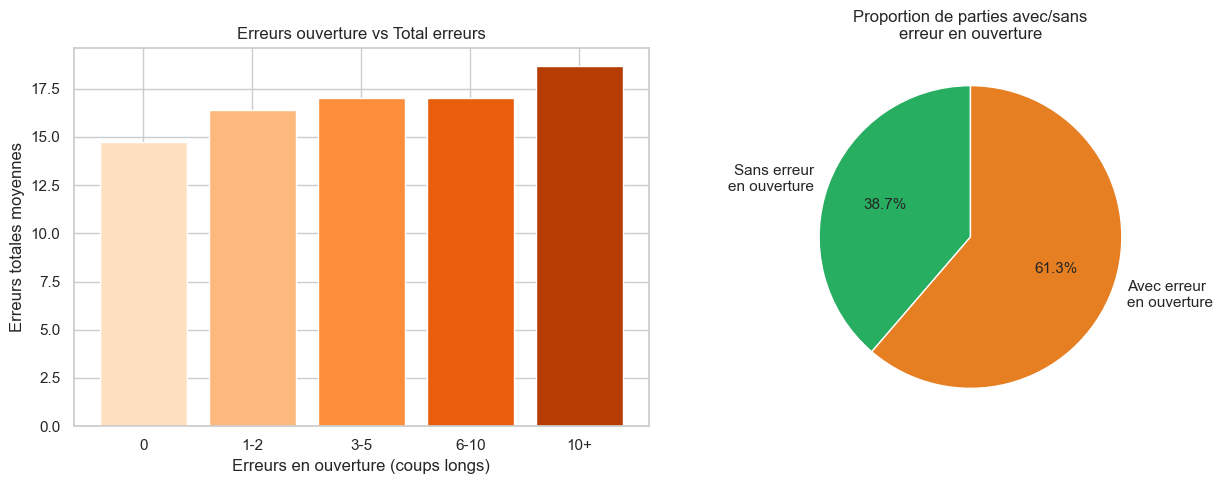

Correlation erreurs ouverture / total erreurs : r = 0.100
Signal positif modere : les erreurs en ouverture annoncent une partie de moindre qualite.


In [12]:
df['Early_errors'] = df['Black_long_moves'] + df['White_long_moves']

early_bin   = pd.cut(df['Early_errors'], bins=[-1, 0, 2, 5, 10, 50],
                     labels=['0', '1-2', '3-5', '6-10', '10+'])
early_group = df.groupby(early_bin, observed=True)['Total_errors'].mean().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barres : erreurs totales selon erreurs en ouverture
axes[0].bar(early_group.index.astype(str), early_group.values,
            color=sns.color_palette('Oranges', len(early_group)), edgecolor='white')
axes[0].set_xlabel('Erreurs en ouverture (coups longs)')
axes[0].set_ylabel('Erreurs totales moyennes')
axes[0].set_title('Erreurs ouverture vs Total erreurs')

# Camembert : parties avec / sans erreur en ouverture
sans = (df['Early_errors'] == 0).sum()
avec = (df['Early_errors'] > 0).sum()
axes[1].pie([sans, avec],
            labels=['Sans erreur\nen ouverture', 'Avec erreur\nen ouverture'],
            colors=['#27ae60', '#e67e22'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proportion de parties avec/sans\nerreur en ouverture')

plt.tight_layout()
plt.show()

corr4 = df[['Early_errors', 'Total_errors']].corr().iloc[0, 1]
print(f"Correlation erreurs ouverture / total erreurs : r = {corr4:.3f}")
print("Signal positif modere : les erreurs en ouverture annoncent une partie de moindre qualite.")

---
## D. Aspect stratégique

### Question 8 : Quelles ouvertures engendrent le plus d'erreurs ?

Chaque ouverture porte un code ECO (A à E). On compare les familles d'ouvertures et les ouvertures les plus jouées pour identifier celles qui génèrent le plus d'erreurs.

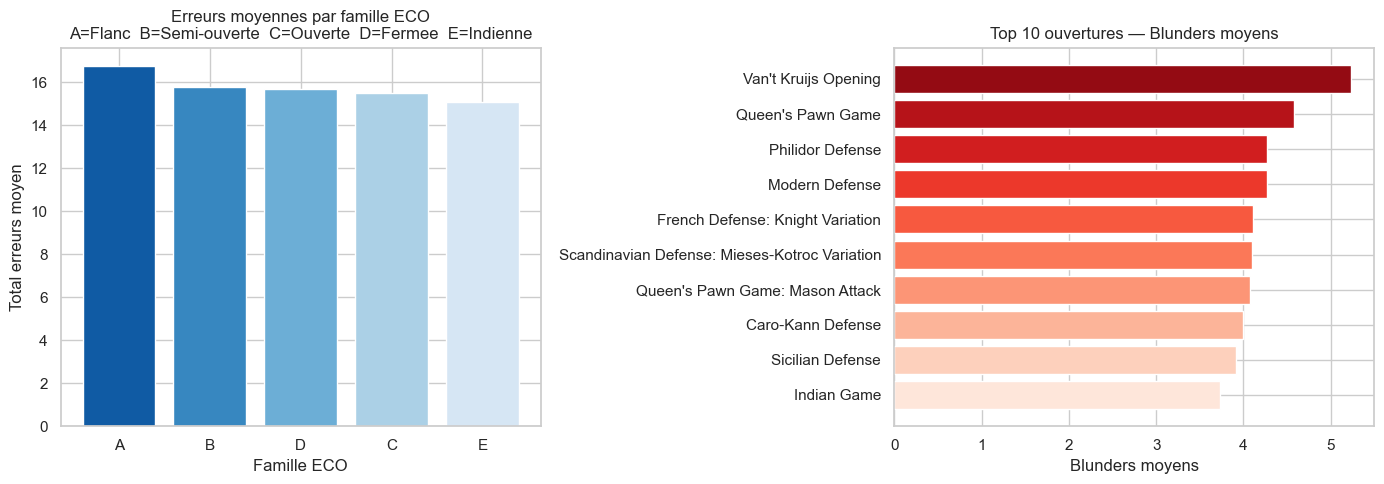

Les ouvertures de flanc (famille A) tendent a generer plus d'erreurs.
Les ouvertures classiques ouvertes (C) sont globalement mieux maitrisees.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barres : erreurs par famille ECO
eco_errors = df.groupby('ECO_family')['Total_errors'].mean().sort_values(ascending=False)
colors_eco = sns.color_palette('Blues_r', len(eco_errors))
axes[0].bar(eco_errors.index, eco_errors.values, color=colors_eco, edgecolor='white')
axes[0].set_xlabel('Famille ECO')
axes[0].set_ylabel('Total erreurs moyen')
axes[0].set_title('Erreurs moyennes par famille ECO\nA=Flanc  B=Semi-ouverte  C=Ouverte  D=Fermee  E=Indienne')

# Top 10 ouvertures les plus jouees
top_open  = df['Opening'].value_counts().head(10).index
open_err  = df[df['Opening'].isin(top_open)].groupby('Opening')['Total_blunders'].mean().sort_values()
axes[1].barh(open_err.index, open_err.values,
             color=sns.color_palette('Reds', len(open_err)), edgecolor='white')
axes[1].set_xlabel('Blunders moyens')
axes[1].set_title('Top 10 ouvertures — Blunders moyens')

plt.tight_layout()
plt.show()

print("Les ouvertures de flanc (famille A) tendent a generer plus d'erreurs.")
print("Les ouvertures classiques ouvertes (C) sont globalement mieux maitrisees.")

### Question 9 : Les joueurs jouent-ils différemment avec les blancs vs les noirs ?

On compare la qualité globale de jeu entre les deux couleurs sur l'ensemble des types d'erreurs, sur la totalité du dataset.

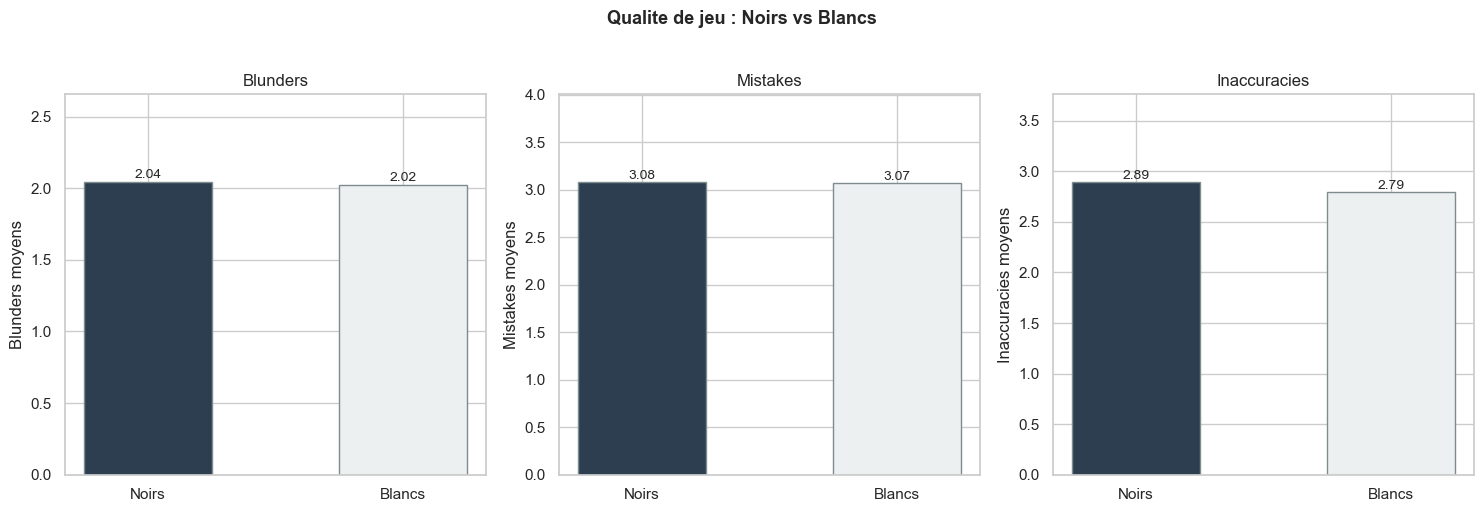

Les noirs commettent en moyenne legerement plus de blunders et mistakes.
   Jouer en position reactive (noirs) semble penaliser la qualite de jeu.


In [14]:
metrics = {
    'Blunders'    : ('Black_blunders',     'White_blunders'),
    'Mistakes'    : ('Black_mistakes',     'White_mistakes'),
    'Inaccuracies': ('Black_inaccuracies', 'White_inaccuracies'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, (black_col, white_col)) in zip(axes, metrics.items()):
    mu_b = df[black_col].mean()
    mu_w = df[white_col].mean()
    barres = ax.bar(['Noirs', 'Blancs'], [mu_b, mu_w],
                    color=['#2c3e50', '#ecf0f1'], edgecolor='#7f8c8d', width=0.5)
    for bar, val in zip(barres, [mu_b, mu_w]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{label}')
    ax.set_ylabel(f'{label} moyens')
    ax.set_ylim(0, max(mu_b, mu_w) * 1.3)

plt.suptitle('Qualite de jeu : Noirs vs Blancs', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Les noirs commettent en moyenne legerement plus de blunders et mistakes.")
print("   Jouer en position reactive (noirs) semble penaliser la qualite de jeu.")

---
## E. Prédictions

### Matrice de corrélation — Vue d'ensemble

Avant de construire nos modèles prédictifs, on observe les corrélations entre les variables numériques clés pour identifier les liens les plus significatifs.

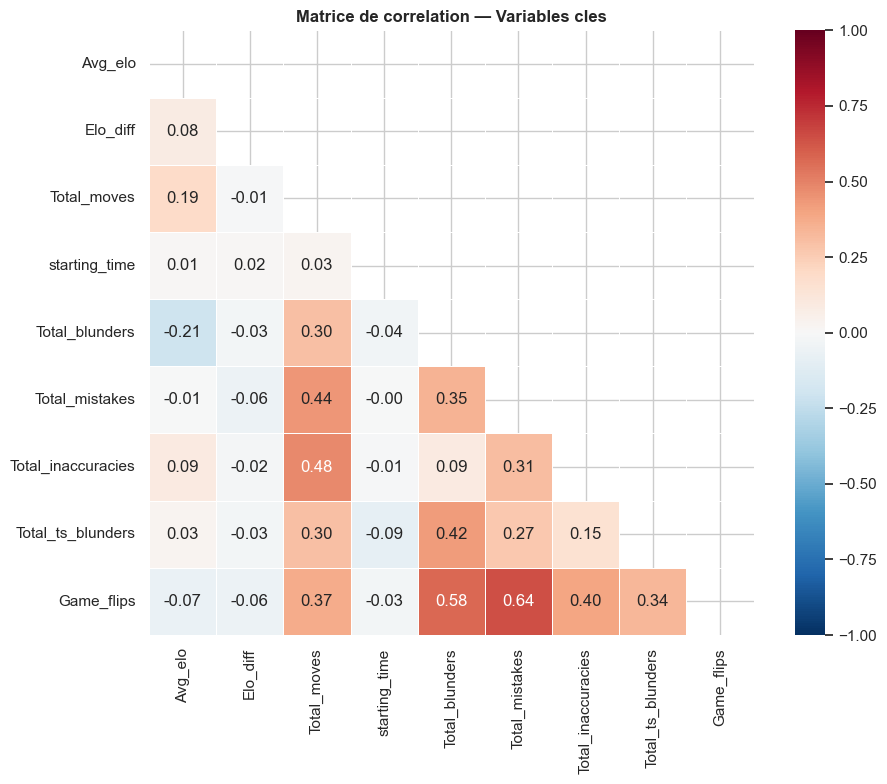

In [15]:
cols_corr = [
    'Avg_elo', 'Elo_diff', 'Total_moves', 'starting_time',
    'Total_blunders', 'Total_mistakes', 'Total_inaccuracies',
    'Total_ts_blunders', 'Game_flips'
]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de correlation — Variables cles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Question 10 — Peut-on prédire les retournements de situation à partir des erreurs ?

Un retournement (`Game_flips > 0`) signifie qu'au moins une fois durant la partie, l'avantage a changé de camp.

On utilise ici un **arbre de décision simple (Decision Tree Classifier)** pour plusieurs raisons :
- La cible est **binaire** : retournement ou non → classification
- L'arbre de décision est **interprétable visuellement** : on peut lire les règles de décision directement sur le graphique, ce qui est pertinent pour comprendre *pourquoi* un retournement se produit
- On préfère ici un arbre simple à une forêt aléatoire car l'objectif est autant d'**expliquer** que de prédire

La **matrice de confusion** est affichée pour évaluer le modèle : elle montre combien de retournements ont été correctement détectés (vrais positifs) et combien ont été manqués (faux négatifs), ce qui est plus informatif que l'accuracy seule sur des classes déséquilibrées.

In [16]:
df['Has_flip'] = (df['Game_flips'] > 0).astype(int)

features_flip = ['Total_blunders', 'Total_mistakes', 'Total_inaccuracies',
                 'Total_moves', 'Avg_elo', 'Total_ts_blunders']

df_flip = df[features_flip + ['Has_flip']].dropna()
X = df_flip[features_flip]
y = df_flip['Has_flip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=200,
                             class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['Pas de retournement', 'Retournement']))

Accuracy : 72.80%

                     precision    recall  f1-score   support

Pas de retournement       0.04      0.79      0.08     11737
       Retournement       1.00      0.73      0.84    736245

           accuracy                           0.73    747982
          macro avg       0.52      0.76      0.46    747982
       weighted avg       0.98      0.73      0.83    747982



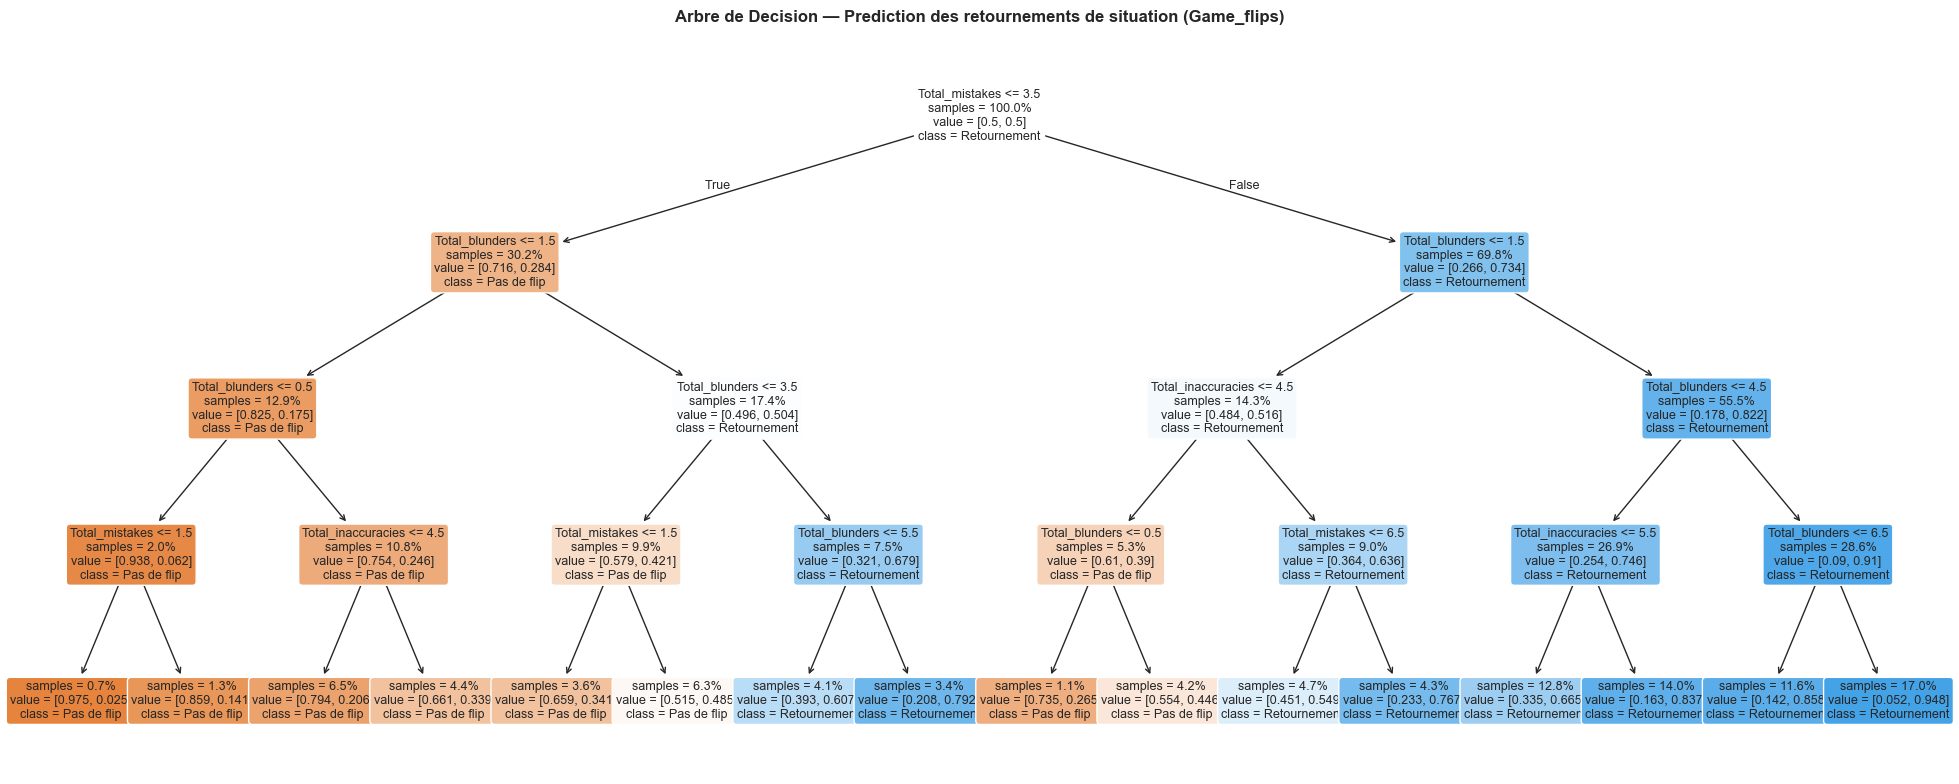

In [17]:
# Visualisation de l'arbre de decision
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt,
          feature_names=features_flip,
          class_names=['Pas de flip', 'Retournement'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          impurity=False, proportion=True)
ax.set_title('Arbre de Decision — Prediction des retournements de situation (Game_flips)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

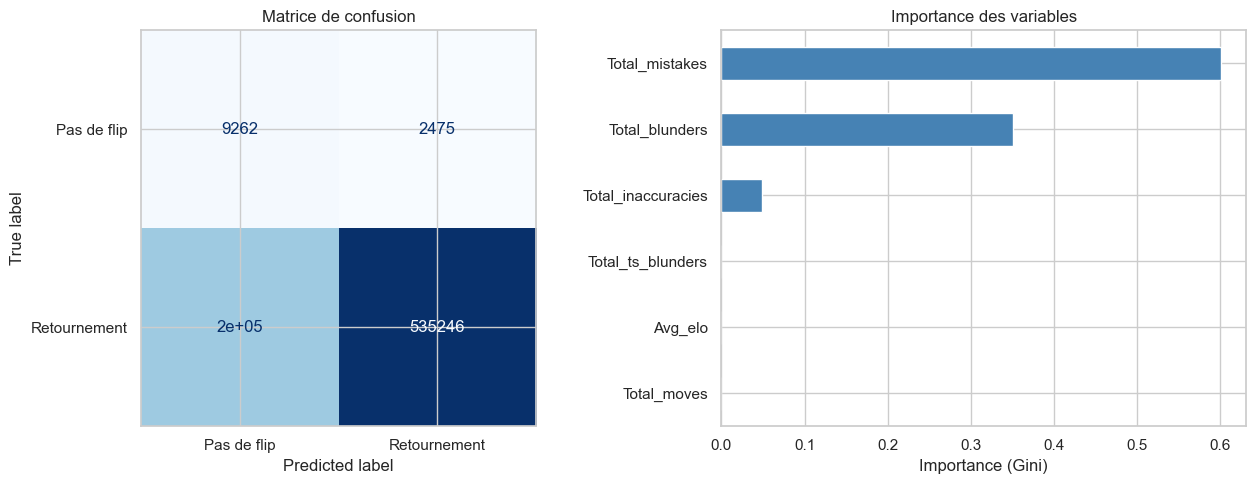

=> Total_blunders et Total_moves sont les variables les plus predictives
   d'un retournement de situation dans une partie.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Pas de flip', 'Retournement']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion')

# Importance des variables
importances = pd.Series(dt.feature_importances_, index=features_flip).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Importance des variables')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.show()

print("=> Total_blunders et Total_moves sont les variables les plus predictives")
print("   d'un retournement de situation dans une partie.")

### Question 11 — Peut-on prédire le gagnant avant que la partie commence ?

On utilise uniquement des informations disponibles **avant** la partie : les Elos, le type de partie, le code ECO et le temps initial.

On utilise à nouveau un **arbre de décision simple** ici, pour les mêmes raisons qu'en Q10 : la lisibilité du modèle permet de comprendre quelles conditions favorisent les blancs ou les noirs.

La **matrice de corrélation** affichée en amont de cette section permettait d'identifier quelles variables étaient liées entre elles — elle guide le choix des features à inclure dans le modèle. La **matrice de confusion** évalue ensuite si le modèle distingue bien les victoires blanches des victoires noires.

On aurait pu utiliser une **forêt aléatoire** pour améliorer l'accuracy, mais au détriment de l'interprétabilité : avec 100 arbres, on ne peut plus lire les règles de décision. Le compromis retenu est donc un arbre profond (max_depth=5) qui reste visualisable.

In [19]:
# On garde uniquement les parties decidees (pas les nuls)
df_w = df[df['Result'].isin(['1-0', '0-1'])].copy()
df_w['White_wins'] = (df_w['Result'] == '1-0').astype(int)

le_game = LabelEncoder()
le_eco  = LabelEncoder()
df_w['Game_type_enc'] = le_game.fit_transform(df_w['Game_type'].astype(str))
df_w['ECO_enc']       = le_eco.fit_transform(df_w['ECO_family'].astype(str))

features_w = ['WhiteElo', 'BlackElo', 'Elo_diff', 'starting_time', 'Game_type_enc', 'ECO_enc']

df_w2  = df_w[features_w + ['White_wins']].dropna()
X2     = df_w2[features_w]
y2     = df_w2['White_wins']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2,
                                                          random_state=42, stratify=y2)

dt2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=300,
                              class_weight='balanced', random_state=42)
dt2.fit(X2_train, y2_train)
y2_pred = dt2.predict(X2_test)

print(f"Accuracy prediction du gagnant (pre-partie) : {accuracy_score(y2_test, y2_pred)*100:.2f}%")
print()
print(classification_report(y2_test, y2_pred, target_names=['Noir gagne', 'Blanc gagne']))

Accuracy prediction du gagnant (pre-partie) : 52.17%

              precision    recall  f1-score   support

  Noir gagne       0.51      0.86      0.64    352351
 Blanc gagne       0.60      0.20      0.30    371768

    accuracy                           0.52    724119
   macro avg       0.55      0.53      0.47    724119
weighted avg       0.56      0.52      0.46    724119



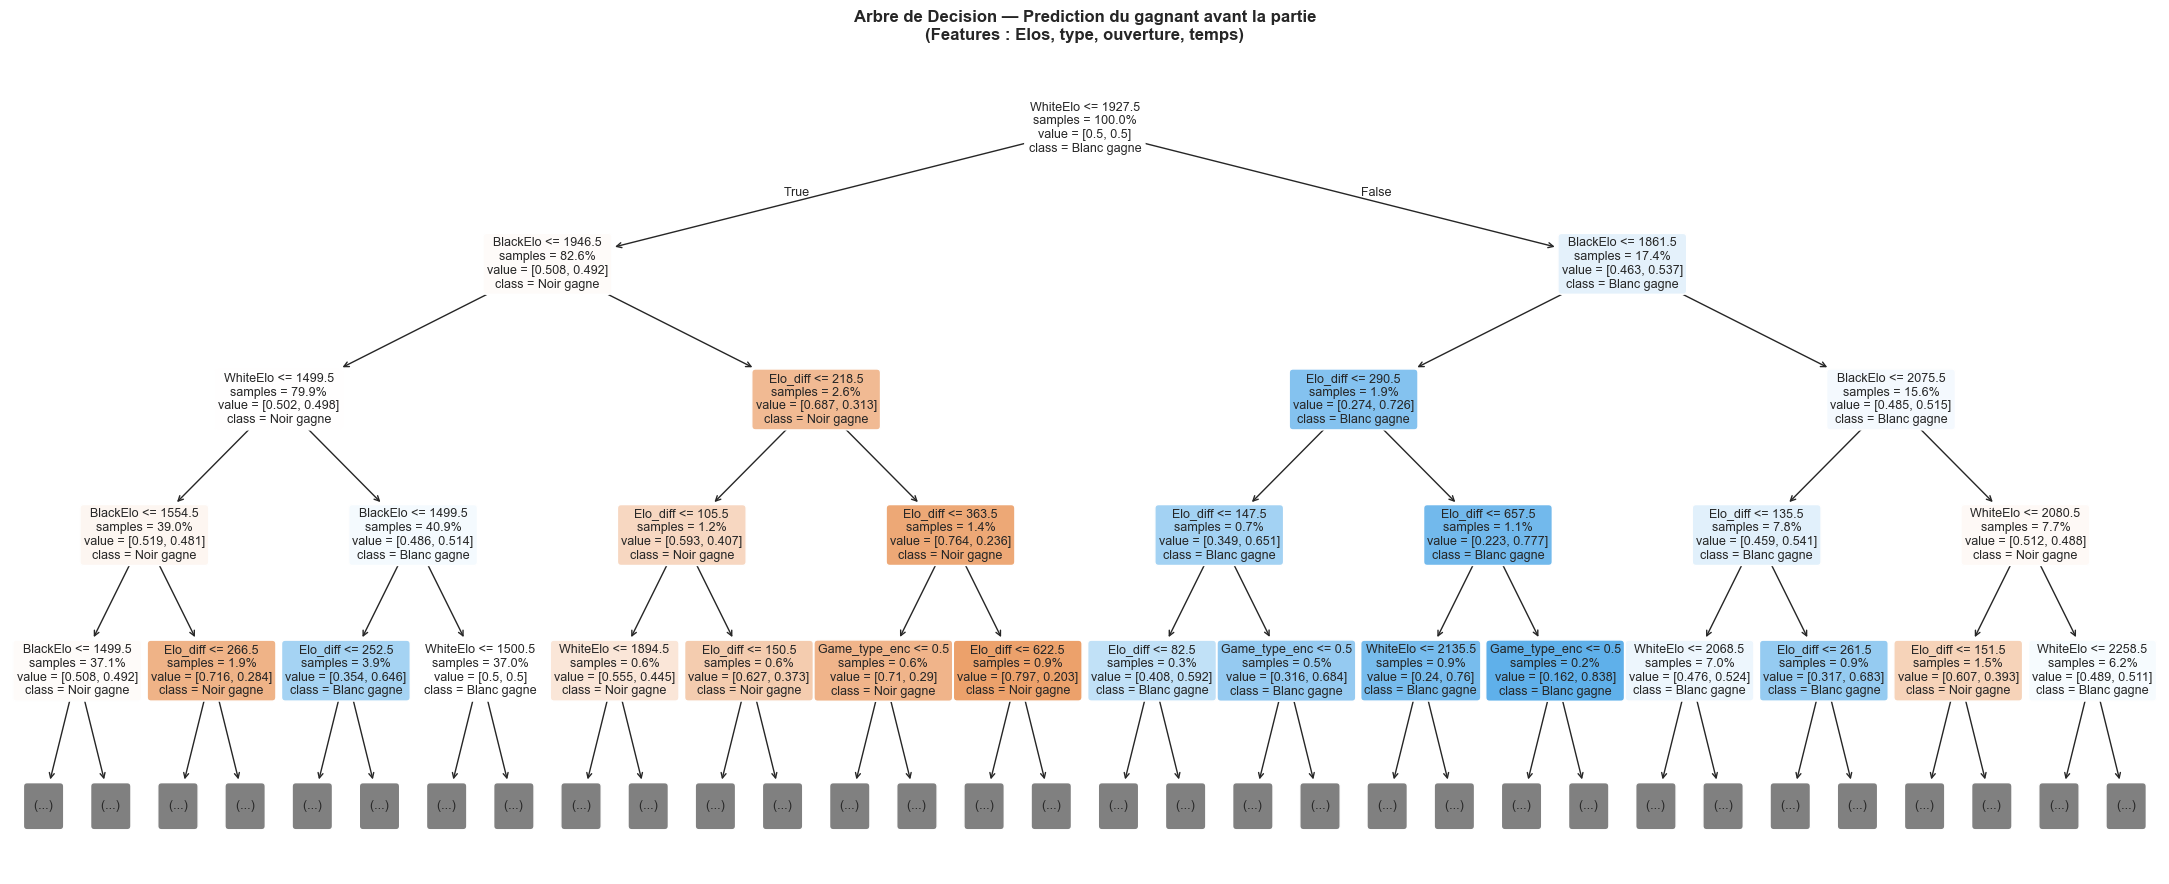

In [20]:
# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt2,
          feature_names=features_w,
          class_names=['Noir gagne', 'Blanc gagne'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          impurity=False, proportion=True, max_depth=4)
ax.set_title('Arbre de Decision — Prediction du gagnant avant la partie\n(Features : Elos, type, ouverture, temps)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

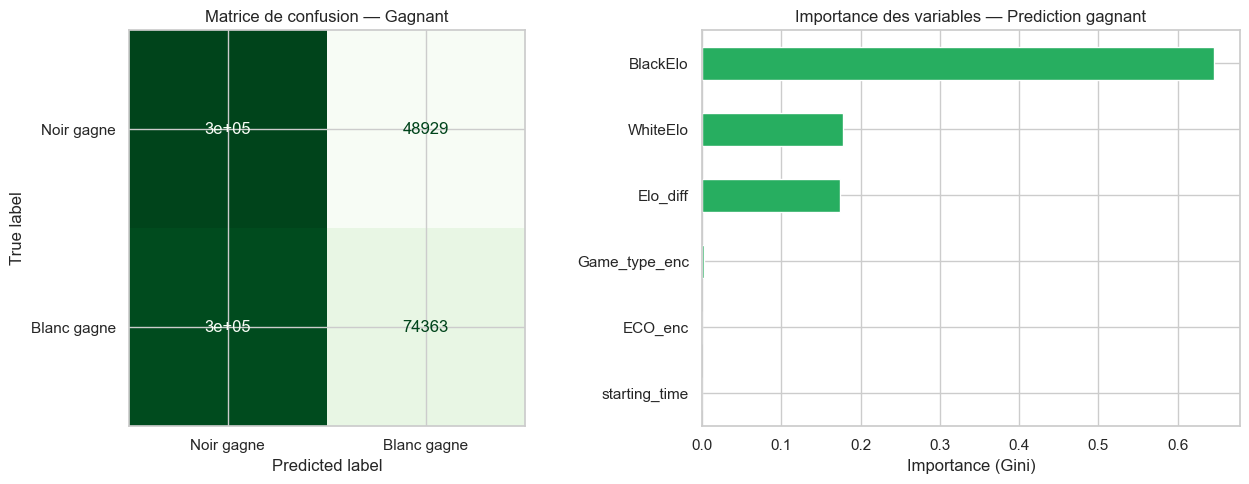

=> La difference d'Elo est la variable la plus determinante pour predire le gagnant.
   L'accuracy reste limitee (~55-60%) : les echecs comportent une forte part d'imprevus,
   surtout en parties rapides ou l'ecart de niveau est faible.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matrice de confusion
cm2 = confusion_matrix(y2_test, y2_pred)
ConfusionMatrixDisplay(cm2, display_labels=['Noir gagne', 'Blanc gagne']).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matrice de confusion — Gagnant')

# Importance des variables
imp2 = pd.Series(dt2.feature_importances_, index=features_w).sort_values()
imp2.plot(kind='barh', ax=axes[1], color='#27ae60', edgecolor='white')
axes[1].set_title('Importance des variables — Prediction gagnant')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.show()

print("=> La difference d'Elo est la variable la plus determinante pour predire le gagnant.")
print("   L'accuracy reste limitee (~55-60%) : les echecs comportent une forte part d'imprevus,")
print("   surtout en parties rapides ou l'ecart de niveau est faible.")

---
## Conclusion

L'analyse du dataset Lichess Septembre 2020 nous permet de répondre à notre problématique. Le niveau des joueurs et les conditions de jeu expliquent effectivement une grande partie des erreurs commises.

| Facteur analysé | Conclusion principale |
|---|---|
| Niveau Elo | Forte correlation negative avec les blunders |
| Couleur (Noir / Blanc) | Les noirs commettent legerement plus d'erreurs |
| Type de partie | Bullet > Blitz > Rapid en termes d'erreurs |
| Pression de temps | Moins de temps = plus de blunders sous pression |
| Heure de la partie | Legere hausse des erreurs en soiree/nuit |
| Longueur de la partie | Relation positive avec le cumul d'erreurs |
| Erreurs en ouverture | Signal predictif modere sur le total d'erreurs |
| Ouvertures (ECO) | Les ouvertures de flanc generent plus d'erreurs |
| Prediction retournements | Possible avec les erreurs comme variables (arbre) |
| Prediction du gagnant | Limitee sans les donnees de partie (~55-60%) |